# Импорт библиотек

In [1]:
import matplotlib.pyplot as plt
from numpy import linspace
from math import ceil, nan, tan, radians

In [2]:
from library import Ra40, d_cuff, get_f, get_spline, get_bearing, get_cuff
from utils import choice

# Исходные данные

In [3]:
n = 6  # количество участков

moment = 402.3  # Н*м
sigma = 100 * 10**6  # Па 100..120

# Присоединительные размеры муфты
d_connection = 48
l_conection = 82

assert d_connection in Ra40, f"{d_connection} не входит в нормальный ряд"

# Размеры подшипников
l_bearing, D_bearing, alpha = 22, 90, radians(26)

In [4]:
# напряжения текучести для изгиба и кручения
sigma_t_, tau_t_ = 500, 350  # Н*м
k = 2.2

In [5]:
# консольная сила (Н)
Fk = 3791.09
# радиальная сила (Н)
Fr = 1161.9
# осевая сила (Н)
Fa = 2076.27
# тангенциальная сила (Н)
Ft = 3192.93

In [6]:
d_ = 252  # мм

ГОСТ 6636–69: 20; 22; 24; 25; 26;28; 30; 32; 34; (35); 36; 38; 40; 42; 45; 48; 50; 53; (55); 56; 60; 63; (65); 67;(70); 71; 75; 80; 85; 90; 95; 100. 

d | 17..22 | 24..30 | 32..38 | 40..44 | 45..50 | 52..58 | 60..65 | 67..75 | 80..85 | 90..95
---|---|---|---|---|---|---|---|---|---|---
r | 1.5 | 2.0 | 2.5 | 2.5 | 3.0 | 3.0 | 3.5 | 3.5 | 3.7 | 4.0
f | 1.0 | 1.0 | 1.2 | 1.2 | 1.6 | 2.0 | 2.0 | 2.5 | 2.5 | 3.0

# Расчет

Диаметры

In [7]:
# Инициализация
d = [nan] * n

# диаметр муфты
d[0] = d_connection

# диаметр манжеты
f = get_f(d[0])
d[1] = d[0] + 3 * f
d[1] = choice(d[1], d_cuff, "ceil")
cuff = get_cuff(d[1])  # манжета

# диаметр подшипника
d[2] = int(ceil(d[1]))
while True:
    d[2] += 1
    if d[2] % 5 == 0:
        break

# диаметр ступицы
f = get_f(d[2])
d[3] = d[2] + 3 * f
d[3] = choice(d[3], Ra40, "nearest")

# диаметр упора колеса
f = get_f(d[3])
d[4] = d[3] + 3 * f
d[4] = choice(d[4], Ra40, "nearest")

# диаметр подшипника
d[5] = d[2]

Длины

In [8]:
# Инициализацияы
l = [nan] * n

# длина посадки муфты
l[0] = l_conection

# длина ступицы
spline = get_spline(d[3])  # шпонка
l[3] = (2 * moment) / (d[3] / 1000 * (spline["h"] - spline["t1"]) / 1000 * sigma)
l[3] *= 1000  # мм
l[3] += spline["b"]
l_spline = choice(l[3], list(range(spline["l_min"], spline["l_max"], 1)), "ceil")
l[3] = l_spline + 10  # 5..10
l[3] = ceil(l[3])

# длина упора колеса
l[4] = 8

# длина подшипника
l[5] = l_bearing

l[2] = l[4] + l_bearing + 1

# толщина стенки корпуска
thickness = ceil(max(1.35 * (moment) ** (1 / 4), 6))

l[1] = 6 + 10 + thickness + 15  # 5 - цил 15 червь

length = sum(l)

a = 0.5 * (l_bearing + (D_bearing - d[2]) / 2 * tan(alpha))

# Результат

In [9]:
for i in range(n):
    print(f"{i}: Ø {d[i]} l={l[i]}")
print(f"{length=}")

0: Ø 48 l=82
1: Ø 55 l=38
2: Ø 60 l=31
3: Ø 65 l=66
4: Ø 71 l=8
5: Ø 60 l=22
length=247


# Визуализация

In [10]:
def show_shaft():
    offset = 5  # смещение размеров от детали

    # plt.axis("equal")
    plt.grid(True)

    plt.plot([0, sum(l)], [0] * 2, color="black", ls="dashdot")  # ось
    plt.plot([l[0] + l[1] + l[2] + l[3] / 2] * 2, [0, d[4]], color="black", ls="dashdot")  # ось колеса

    # диаметры
    plt.plot(2 * [0], [0, d[0] / 2], color="black", ls="solid")
    plt.plot(2 * [l[0]], [0, d[1] / 2], color="black", ls="solid")
    plt.plot(2 * [l[0] + l[1]], [0, d[2] / 2], color="black", ls="solid")
    plt.plot(2 * [l[0] + l[1] + l[2]], [0, d[3] / 2], color="black", ls="solid")
    plt.plot(2 * [l[0] + l[1] + l[2] + l[3]], [0, d[4] / 2], color="black", ls="solid")
    plt.plot(2 * [l[0] + l[1] + l[2] + l[3] + l[4]], [0, d[4] / 2], color="black", ls="solid")
    plt.plot(2 * [l[0] + l[1] + l[2] + l[3] + l[4] + l[5]], [0, d[5] / 2], color="black", ls="solid")

    # линейные участки
    plt.plot([0, l[0]], [d[0] / 2] * 2, color="black", ls="solid")
    plt.plot([l[0], l[0] + l[1]], [d[1] / 2] * 2, color="black", ls="solid")
    plt.plot([l[0] + l[1], l[0] + l[1] + l[2]], [d[2] / 2] * 2, color="black", ls="solid")
    plt.plot([l[0] + l[1] + l[2], l[0] + l[1] + l[2] + l[3]], [d[3] / 2] * 2, color="black", ls="solid")
    plt.plot([l[0] + l[1] + l[2] + l[3], l[0] + l[1] + l[2] + l[3] + l[4]], [d[4] / 2] * 2, color="black", ls="solid")
    plt.plot([l[0] + l[1] + l[2] + l[3] + l[4], l[0] + l[1] + l[2] + l[3] + l[4] + l[5]], [d[5] / 2] * 2, color="black", ls="solid")

    # диаметральные размеры
    plt.text(0 - offset, d[0] / 4, f"Ø{d[0]:.1f}", color="black", fontsize=12, ha="center", va="center", rotation=90)
    plt.text(0 + l[0] - offset, d[1] / 4, f"Ø{d[1]:.1f}", color="black", fontsize=12, ha="center", va="center", rotation=90)
    plt.text(0 + l[0] + l[1] - offset, d[2] / 4, f"Ø{d[2]:.1f}", color="black", fontsize=12, ha="center", va="center", rotation=90)
    plt.text(0 + l[0] + l[1] + l[2] - offset, d[3] / 4, f"Ø{d[3]:.1f}", color="black", fontsize=12, ha="center", va="center", rotation=90)
    plt.text(0 + l[0] + l[1] + l[2] + l[3] - offset, d[4] / 4, f"Ø{d[4]:.1f}", color="black", fontsize=12, ha="center", va="center", rotation=90)
    plt.text(0 + l[0] + l[1] + l[2] + l[3] + l[4] + l[5] - offset, d[5] / 4, f"Ø{d[5]:.1f}", color="black", fontsize=12, ha="center", va="center", rotation=90)

    # линейные размеры
    plt.text(l[0] / 2, -offset, f"{l[0]:.1f}", color="black", fontsize=12, ha="center", va="center")
    plt.text(l[0] + l[1] / 2, -offset, f"{l[1]:.1f}", color="black", fontsize=12, ha="center", va="center")
    plt.text(l[0] + l[1] + l[2] / 2, -offset, f"{l[2]:.1f}", color="black", fontsize=12, ha="center", va="center")
    plt.text(l[0] + l[1] + l[2] + l[3] / 2, -offset, f"{l[3]:.1f}", color="black", fontsize=12, ha="center", va="center")
    plt.text(l[0] + l[1] + l[2] + l[3] + l[4] / 2, -offset, f"{l[4]:.1f}", color="black", fontsize=12, ha="center", va="center")
    plt.text(l[0] + l[1] + l[2] + l[3] + l[4] + l[5] / 2, -offset, f"{l[5]:.1f}", color="black", fontsize=12, ha="center", va="center")

    # шпонка
    plt.plot(2 * [l[0] + l[1] + l[2] + l[3] / 2 - l_spline / 2], [d[3] / 2, d[3] / 2 - spline["t1"]], color="black", ls="solid")
    plt.plot([l[0] + l[1] + l[2] + l[3] / 2 - l_spline / 2, l[0] + l[1] + l[2] + l[3] / 2 + l_spline / 2], [d[3] / 2 - spline["t1"]] * 2, color="black", ls="solid")
    plt.plot(2 * [l[0] + l[1] + l[2] + l[3] / 2 + l_spline / 2], [d[3] / 2, d[3] / 2 - spline["t1"]], color="black", ls="solid")

    # размер шпонки
    plt.text(l[0] + l[1] + l[2] + l[3] / 2 - offset, (d[4] - spline["t1"]) / 2, f"{spline['t1']}", color="black", fontsize=12, ha="center", va="center", rotation=90)

    # втулка
    plt.plot(2 * [l[0] + l[1] + l[2] - 8], [d[2] / 2, d[4] / 2], color="black", ls="solid")
    plt.plot(2 * [l[0] + l[1] + l[2] - 0], [d[2] / 2, d[4] / 2], color="black", ls="solid")
    plt.plot([l[0] + l[1] + l[2] - 8, l[0] + l[1] + l[2]], [d[4] / 2] * 2, color="black", ls="solid")

    # Левый подшипник
    plt.plot(
        [
            l[0] + l[1] + 1,
            l[0] + l[1] + 1,
            l[0] + l[1] + 1 + l_bearing,
            l[0] + l[1] + 1 + l_bearing,
        ],
        [d[2] / 2, D_bearing / 2, D_bearing / 2, d[2] / 2],
        color="black",
        ls="solid",
    )
    # Правый подшипник
    plt.plot(
        [
            l[0] + l[1] + l[2] + l[3] + l[4],
            l[0] + l[1] + l[2] + l[3] + l[4],
            l[0] + l[1] + l[2] + l[3] + l[4] + l_bearing,
            l[0] + l[1] + l[2] + l[3] + l[4] + l_bearing,
        ],
        [d[2] / 2, D_bearing / 2, D_bearing / 2, d[2] / 2],
        color="black",
        ls="solid",
    )

    # Левая настоящая опора
    plt.plot(
        [l[0] + l[1] + 1 + l_bearing / 2, l[0] + l[1] + 1 + l_bearing / 2 + a],
        [(D_bearing + d[2]) / 2 / 2, 0],
        color="blue",
        ls="dashdot",
    )
    # Правая настоящая опора
    plt.plot(
        [l[0] + l[1] + l[2] + l[3] + l[4] + l_bearing / 2, l[0] + l[1] + l[2] + l[3] + l[4] + l_bearing / 2 - a],
        [(D_bearing + d[2]) / 2 / 2, 0],
        color="blue",
        ls="dashdot",
    )

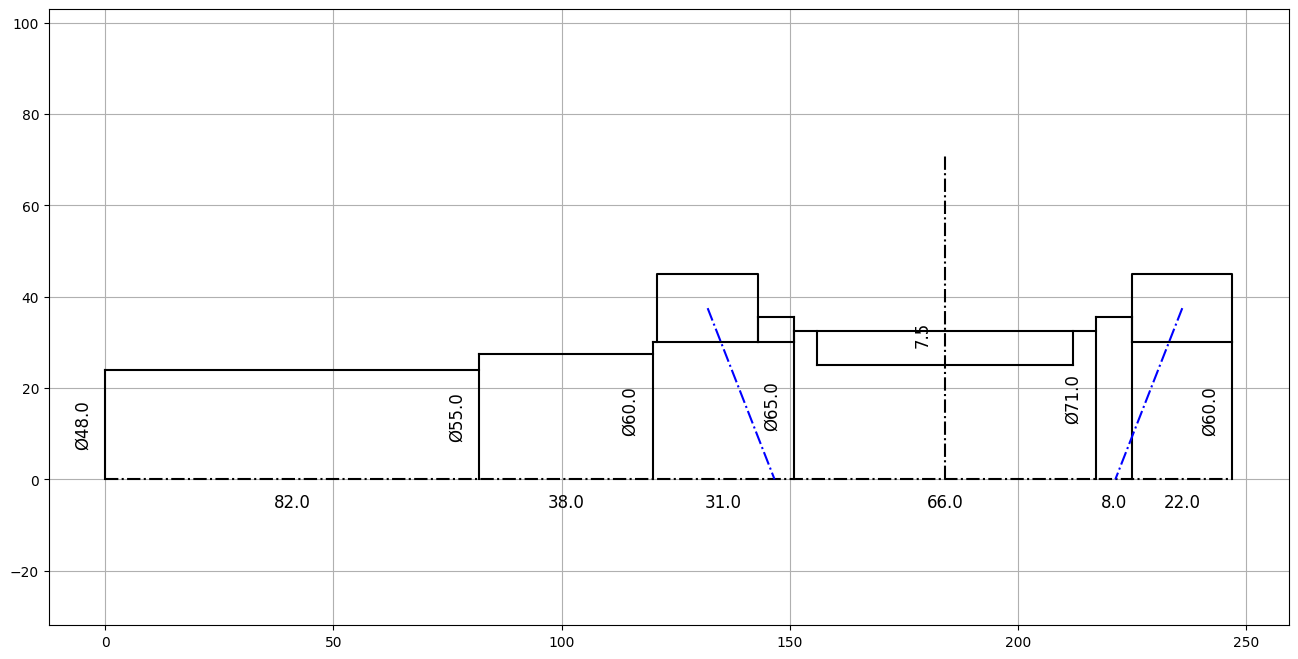

In [11]:
plt.figure(figsize=(16, 8))
plt.axis("equal")
show_shaft();

# Расчет реакций

In [12]:
# расстояние до консольной силы, до подшипников (мм)
lb = length - (l[0] + l[1] + l[2] + l[3] / 2) - l_bearing / 2 - a  # длина - ось колеса - пол подшипника - смещение
lk = (l[0] + l[1] + l[2] + l[3] / 2) - lb - l[0] / 2

Горизонтальная плоскость

In [13]:
X_A = (Fk * (lk + 2 * lb) + Fa * (d_ / 2) + Fr * (lb)) / (2 * lb)
X_B = (-Fk * (lk) - Fa * (d_ / 2) + Fr * lb) / (2 * lb)

print(f"{X_A=:.1f}")
print(f"{X_B=:.1f}")

X_A=13238.3
X_B=-8285.3


Проверка

In [14]:
assert abs(X_A + X_B - Fr - Fk) < 1

Вертикальная плоскость

In [15]:
Y_A = (Ft * lb) / (2 * lb)
Y_B = (Ft * lb) / (2 * lb)

print(f"{Y_A=:.1f}")
print(f"{Y_B=:.1f}")

Y_A=1596.5
Y_B=1596.5


Проверка

In [16]:
assert abs(Y_A + Y_B - Ft) < 1

Максимальные реации опор

In [17]:
R_A = (X_A**2 + Y_A**2) ** 0.5
R_B = (X_B**2 + Y_B**2) ** 0.5

print(f"{R_A=:.1f}")
print(f"{R_B=:.1f}")

R_A=13334.2
R_B=8437.7


In [18]:
dx = l[0] / 2

In [19]:
def Mx(x) -> float:
    x = x - dx
    if 0 <= x <= lk:
        return Fk * (x)
    elif lk <= x <= lk + lb:
        return Fk * (x) - X_A * (x - lk)
    elif lk + lb <= x <= lk + lb * 2:
        return Fk * (x) - X_A * (x - lk) + Fa * (d_ / 2) + Fr * (x - lk - lb)
    else:
        return nan


def My(x) -> float:
    x = x - dx
    if 0 <= x <= lk:
        return 0
    elif lk <= x <= lk + lb:
        return 0 + Y_A * (x - lk)
    elif lk + lb <= x <= lk + lb * 2:
        return 0 + Y_A * (x - lk) - Ft * (x - lk - lb)
    else:
        return nan


def Mz(x) -> float:
    x = x - dx
    if 0 <= x <= lk + lb:
        return Ft * (d_ / 2)
    else:
        return 0

In [20]:
def dl(x) -> float:
    if 0 <= x <= l[0]:
        return d[0]
    elif l[0] <= x <= l[0] + l[1]:
        return d[1]
    elif l[0] + l[1] <= x <= l[0] + l[1] + l[2]:
        return d[2]
    elif l[0] + l[1] + l[2] <= x <= l[0] + l[1] + l[2] + l[3]:
        return d[3]
    elif l[0] + l[1] + l[2] + l[3] <= x <= l[0] + l[1] + l[2] + l[3] + l[4]:
        return d[4]
    elif l[0] + l[1] + l[2] + l[3] + l[4] <= x <= l[0] + l[1] + l[2] + l[3] + l[4] + l[5]:
        return d[5]
    else:
        return nan

# Построение эпюр

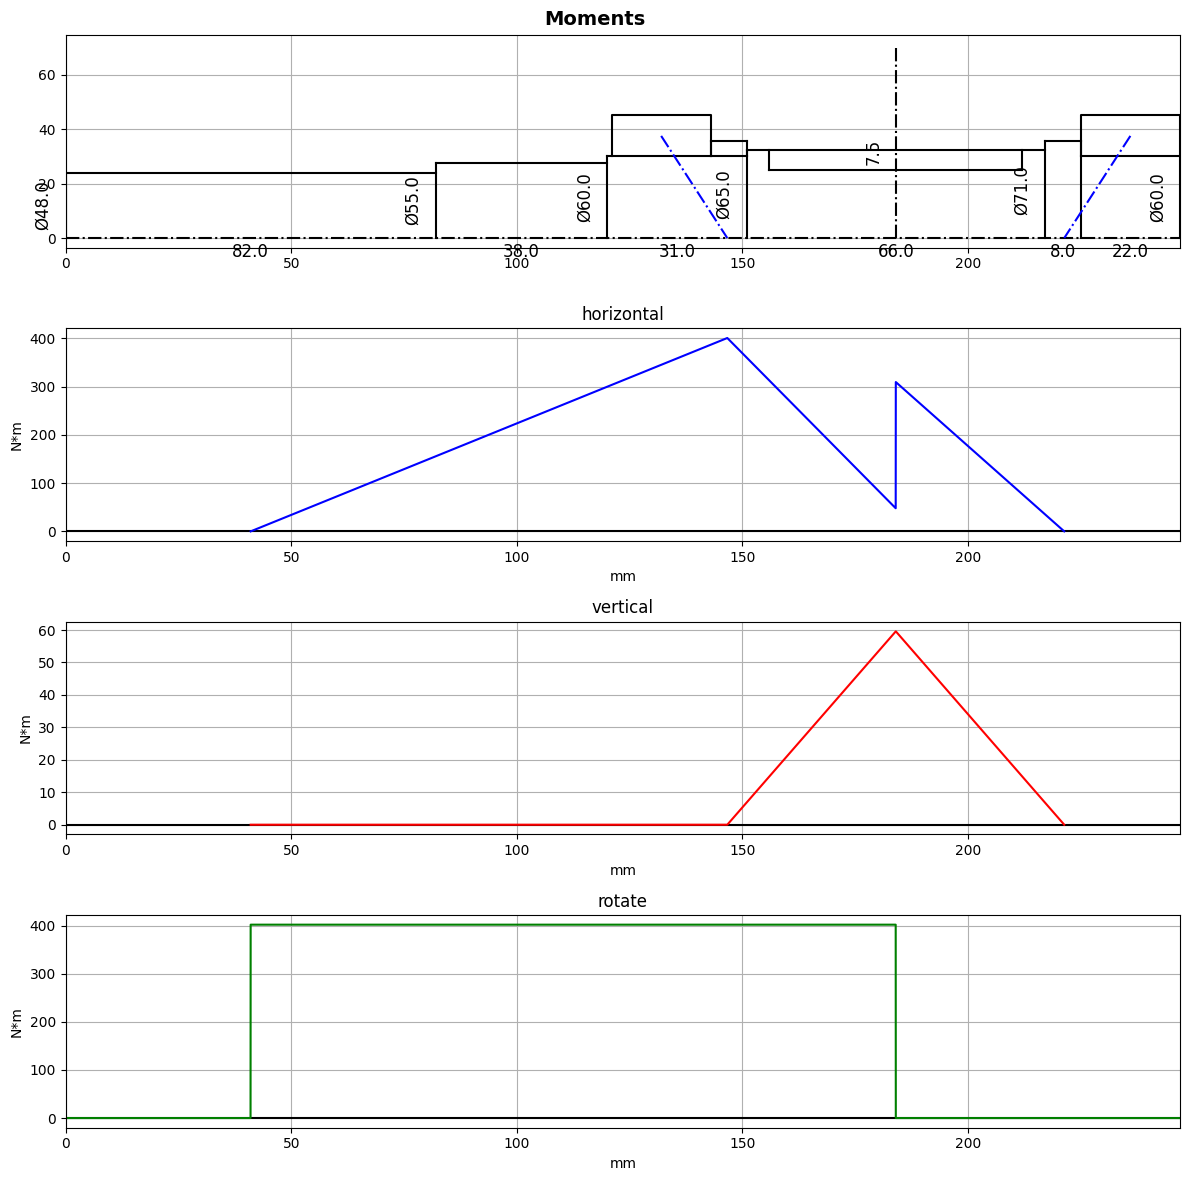

In [21]:
x = linspace(0, length, 10_000, endpoint=True)

fg = plt.figure(figsize=(12, 12))
fg.suptitle("Moments", fontsize=14, fontweight="bold")
gs = fg.add_gridspec(4, 1)  # строки = контуры + валы + спецификация, столбцы

fg.add_subplot(gs[0, 0])
show_shaft()
plt.xlim(0, length)

fg.add_subplot(gs[1, 0])
plt.title("horizontal")
plt.xlabel("mm")
plt.ylabel("N*m")
plt.grid(True)
plt.xlim(0, length)

plt.plot([0, length], [0] * 2, color="black")
plt.plot(x, [Mx(x) / 1000 for x in x], color="blue")

fg.add_subplot(gs[2, 0])
plt.title("vertical")
plt.xlabel("mm")
plt.ylabel("N*m")
plt.grid(True)
plt.xlim(0, length)

plt.plot([0, length], [0] * 2, color="black")
plt.plot(x, [My(x) / 1000 for x in x], color="red")

fg.add_subplot(gs[3, 0])
plt.title("rotate")
plt.xlabel("mm")
plt.ylabel("N*m")
plt.grid(True)
plt.xlim(0, length)

plt.plot([0, length], [0] * 2, color="black")
plt.plot(x, [Mz(x) / 1000 for x in x], color="green")

plt.tight_layout()
plt.show()

# Напряжения и коэф. запаса

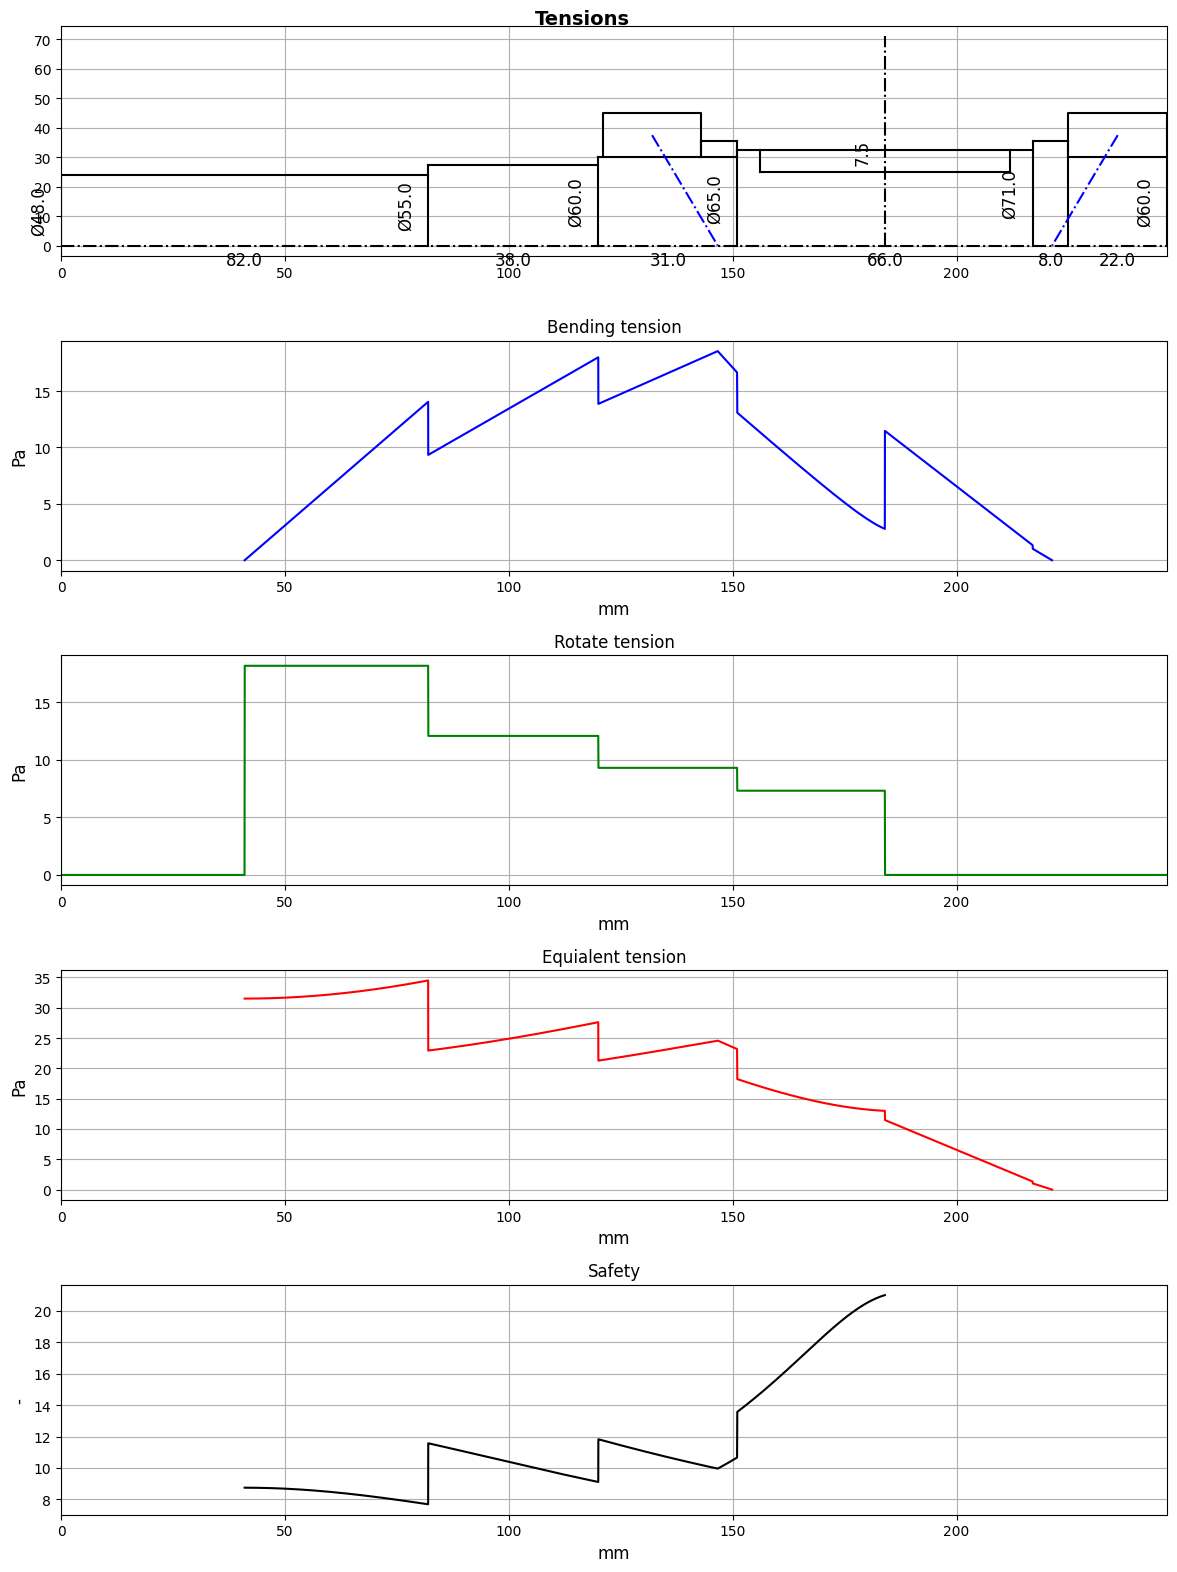

In [22]:
Wu = lambda x: 0.1 * dl(x) ** 3
Wp = lambda x: 0.2 * dl(x) ** 3

sigma_u = lambda x: ((Mx(x) ** 2 + My(x) ** 2) ** 0.5) / Wu(x)
tau = lambda x: Mz(x) / Wp(x)
sigma_eq = lambda x: (sigma_u(x) ** 2 + 3 * tau(x) ** 2) ** 0.5

S_sigma = lambda x: sigma_t_ / (k * sigma_u(x)) if sigma_u(x) != 0 else nan
S_tau = lambda x: tau_t_ / (k * tau(x)) if tau(x) != 0 else nan


def S(x):
    if ((S_sigma(x)) ** 2 + S_tau(x) ** 2) == 0:
        return nan
    else:
        return (S_sigma(x) * S_tau(x)) / (((S_sigma(x)) ** 2 + S_tau(x) ** 2) ** 0.5)


fg = plt.figure(figsize=(12, 16))
fg.suptitle("Tensions", fontsize=14, fontweight="bold")
gs = fg.add_gridspec(5, 1)

fg.add_subplot(gs[0, 0])
show_shaft()
plt.xlim(0, length)

fg.add_subplot(gs[1, 0])
plt.title("Bending tension")
plt.xlabel("mm", fontsize=12)
plt.ylabel("Pa", fontsize=12)
plt.grid(True)
plt.xlim(0, length)
plt.plot(x, [sigma_u(x) for x in x], color="blue")

fg.add_subplot(gs[2, 0])
plt.title("Rotate tension")
plt.xlabel("mm", fontsize=12)
plt.ylabel("Pa", fontsize=12)
plt.grid(True)
plt.xlim(0, length)
plt.plot(x, [tau(x) for x in x], color="green")

fg.add_subplot(gs[3, 0])
plt.title("Equialent tension")
plt.xlabel("mm", fontsize=12)
plt.ylabel("Pa", fontsize=12)
plt.grid(True)
plt.xlim(0, length)
plt.plot(x, [sigma_eq(x) for x in x], color="red")

fg.add_subplot(gs[4, 0])
plt.title("Safety")
plt.xlabel("mm", fontsize=12)
plt.ylabel("-", fontsize=12)
plt.grid(True)
plt.xlim(0, length)
plt.plot(x, [S(x) for x in x], color="black")

plt.tight_layout()
plt.show()